# Extract Embeddings


## **Connect Colab**

In [1]:
import os, sys, subprocess
from getpass import getpass

os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

REPO   = "silvergjeka22/Unified-Lifelong-Action-Learning"
BRANCH = "embeddings"
ROOT   = "/content/ulal"

token = os.environ.get("GITHUB_TOKEN") or getpass("GitHub token: ")
os.environ["GITHUB_TOKEN"] = token

if os.path.isdir(os.path.join(ROOT, ".git")):
    subprocess.run(["git", "-C", ROOT, "fetch", "--depth", "1", "origin", BRANCH], check=True)
    subprocess.run(["git", "-C", ROOT, "reset", "--hard", "FETCH_HEAD"], check=True)
else:
    subprocess.run(["git", "clone", "--depth", "1", "--branch", BRANCH,
                    "https://" + token + "@github.com/" + REPO + ".git", ROOT], check=True)

if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

In [2]:
os.environ["KAGGLE_USERNAME"] = "colab"
os.environ["KAGGLE_KEY"]      = "KGAT_0243645546b65a35088968bb52612f04"

## **Download DATASET**

In [3]:
from src.bootstrap import setup
setup(drive=True, dataset=True)

Mounted at /content/drive
Drive mounted.


100%|██████████| 6.53G/6.53G [06:34<00:00, 17.8MB/s]  

Extracting files...


ULAL_DATASET_ROOT = /root/.cache/kagglehub/datasets/matthewjansen/ucf101-action-recognition/versions/4/
ULAL_OUTPUT_ROOT  = /content/ucf101-processed/
ULAL_DATA_ROOT     = /content/UCF101
ULAL_DRIVE_PROJECT = /content/drive/MyDrive/apai
Setup complete — no config.py edit, no kernel restart.


In [4]:
# imports
%run /content/ulal/src/imports.py
set_seed(cfg.SEED)

ULAL_ROOT : /content/ulal
Device    : cuda
GPU       : Tesla T4 (15.6 GB)
Classes   : base=10 t1=10 t2=10 t3=10 t4=10


42

## **Preprocess data**

In [ ]:
leaking = check_group_leakage(cfg.SELECTED_CLASSES + cfg.TASK_1 + cfg.TASK_2)

classes checked : 30
videos          : 4011
groups          : 750
groups in >1 split: 585

LEAKAGE: 78.0% of groups span multiple splits.
Clips from one source video are in both train and test, so every
accuracy and the probe ceiling are inflated. Re-split by group.
  v_ApplyEyeMakeup_g01               ['test', 'train']
  v_ApplyEyeMakeup_g02               ['test', 'train']
  v_ApplyEyeMakeup_g03               ['train', 'val']
  v_ApplyEyeMakeup_g04               ['test', 'train']
  v_ApplyEyeMakeup_g05               ['test', 'train', 'val']
  v_ApplyEyeMakeup_g06               ['test', 'train', 'val']
  v_ApplyEyeMakeup_g07               ['train', 'val']
  v_ApplyEyeMakeup_g08               ['train', 'val']
  v_ApplyEyeMakeup_g09               ['test', 'train', 'val']
  v_ApplyEyeMakeup_g10               ['test', 'train']


`build_group_split` assigns WHOLE groups to one split, so no frame of a test video can
appear in training. 18 / 3 / 4 of the 25 groups per class gives roughly 72 / 12 / 16
percent. Deterministic by group index, no seed needed.

In [6]:
base_split  = build_group_split(cfg.SELECTED_CLASSES, train_groups=18, val_groups=3)
task1_split = build_group_split(cfg.TASK_1,           train_groups=18, val_groups=3)
task2_split = build_group_split(cfg.TASK_2,           train_groups=18, val_groups=3)

In [7]:
clashes_base  = describe_group_split(base_split,  cfg.SELECTED_CLASSES)
clashes_task1 = describe_group_split(task1_split, cfg.TASK_1)
clashes_task2 = describe_group_split(task2_split, cfg.TASK_2)

split      clips   percent  clips/class
---------------------------------------
train        953     71.7%         95.3
val          165     12.4%         16.5
test         212     15.9%         21.2
---------------------------------------
TOTAL       1330                  133.0

groups: 250   groups in >1 split: 0
OK - group-disjoint.
split      clips   percent  clips/class
---------------------------------------
train        936     71.7%         93.6
val          153     11.7%         15.3
test         217     16.6%         21.7
---------------------------------------
TOTAL       1306                  130.6

groups: 250   groups in >1 split: 0
OK - group-disjoint.
split      clips   percent  clips/class
---------------------------------------
train        991     72.1%         99.1
val          158     11.5%         15.8
test         226     16.4%         22.6
---------------------------------------
TOTAL       1375                  137.5

groups: 250   groups in >1 split: 0
OK - gr

Do not run the next cell unless all three checks above say `OK - group-disjoint`.

In [9]:
# BASE
cfg.OUTPUT_ROOT = cfg.BASE_ROOT
preprocess_group_split(base_split, cfg.SELECTED_CLASSES)

# TASK 1
cfg.OUTPUT_ROOT = cfg.TASK1_ROOT
preprocess_group_split(task1_split, cfg.TASK_1)

# TASK 2
cfg.OUTPUT_ROOT = cfg.TASK2_ROOT
preprocess_group_split(task2_split, cfg.TASK_2)


--- Preprocessing (group-disjoint) ---
To  : /content/UCF101/grouped_base
Classes: 10

Processing split: train



Processing split: val



Processing split: test



Done! Dataset ready at: /content/UCF101/grouped_base

--- Preprocessing (group-disjoint) ---
To  : /content/UCF101/grouped_task1
Classes: 10

Processing split: train



Processing split: val



Processing split: test



Done! Dataset ready at: /content/UCF101/grouped_task1

--- Preprocessing (group-disjoint) ---
To  : /content/UCF101/grouped_task2
Classes: 10

Processing split: train



Processing split: val



Processing split: test



Done! Dataset ready at: /content/UCF101/grouped_task2


In [10]:
cfg.SELECTED_CLASSES

['PlayingTabla',
 'PommelHorse',
 'JumpingJack',
 'PushUps',
 'PoleVault',
 'HorseRace',
 'HighJump',
 'Drumming',
 'HorseRiding',
 'Diving']

In [11]:
print(cfg.SELECTED_CLASSES + cfg.TASK_1)

['PlayingTabla', 'PommelHorse', 'JumpingJack', 'PushUps', 'PoleVault', 'HorseRace', 'HighJump', 'Drumming', 'HorseRiding', 'Diving', 'ApplyEyeMakeup', 'ApplyLipstick', 'Archery', 'BabyCrawling', 'BalanceBeam', 'BandMarching', 'BlowDryHair', 'BlowingCandles', 'BodyWeightSquats', 'Bowling']


In [12]:
# This notebook writes the cache, so the label space is fixed here.
ALL_CLASSES_LIST = cfg.SELECTED_CLASSES + cfg.TASK_1 + cfg.TASK_2

class_to_idx = {cls_name: i for i, cls_name in enumerate(ALL_CLASSES_LIST)}

print(f"\nclass_to_idx:\n{class_to_idx}")


class_to_idx:
{'PlayingTabla': 0, 'PommelHorse': 1, 'JumpingJack': 2, 'PushUps': 3, 'PoleVault': 4, 'HorseRace': 5, 'HighJump': 6, 'Drumming': 7, 'HorseRiding': 8, 'Diving': 9, 'ApplyEyeMakeup': 10, 'ApplyLipstick': 11, 'Archery': 12, 'BabyCrawling': 13, 'BalanceBeam': 14, 'BandMarching': 15, 'BlowDryHair': 16, 'BlowingCandles': 17, 'BodyWeightSquats': 18, 'Bowling': 19, 'BoxingPunchingBag': 20, 'BoxingSpeedBag': 21, 'BrushingTeeth': 22, 'CliffDiving': 23, 'CricketBowling': 24, 'CricketShot': 25, 'CuttingInKitchen': 26, 'FieldHockeyPenalty': 27, 'Haircut': 28, 'SoccerPenalty': 29}


In [13]:
TASK_CLASSES = [cfg.SELECTED_CLASSES, cfg.TASK_1, cfg.TASK_2]
TASK_ROOTS   = [cfg.BASE_ROOT, cfg.TASK1_ROOT, cfg.TASK2_ROOT]
TASK_NAMES   = ["Base", "Task1", "Task2"]

print(f"Base : {len(cfg.SELECTED_CLASSES)} classes  labels 0-{len(cfg.SELECTED_CLASSES)-1}")
print(f"Task1: {len(cfg.TASK_1)} classes  labels {len(cfg.SELECTED_CLASSES)}-{len(cfg.SELECTED_CLASSES)+len(cfg.TASK_1)-1}")
print(f"Task2: {len(cfg.TASK_2)} classes  labels {len(cfg.SELECTED_CLASSES)+len(cfg.TASK_1)}-{len(ALL_CLASSES_LIST)-1}")
print(f"TOTAL: {len(ALL_CLASSES_LIST)} classes")

Base : 10 classes  labels 0-9
Task1: 10 classes  labels 10-19
Task2: 10 classes  labels 20-29
TOTAL: 30 classes


## **Create Loaders**

Loaders over the raw `.pt` clips. They are used twice: once to test the teacher, once
to extract the features. After that nothing reads video again.

In [20]:
CLIP_BATCH = cfg.BATCH_SIZE
PIN_MEMORY = device.type == "cuda"

# BASE
base_train_ds, base_train_loader = build_clip_loader(cfg.BASE_ROOT, cfg.SELECTED_CLASSES, class_to_idx, "train", CLIP_BATCH, cfg.NUM_WORKERS, PIN_MEMORY)
base_val_ds,   base_val_loader   = build_clip_loader(cfg.BASE_ROOT, cfg.SELECTED_CLASSES, class_to_idx, "val",   CLIP_BATCH, cfg.NUM_WORKERS, PIN_MEMORY)
base_test_ds,  base_test_loader  = build_clip_loader(cfg.BASE_ROOT, cfg.SELECTED_CLASSES, class_to_idx, "test",  CLIP_BATCH, cfg.NUM_WORKERS, PIN_MEMORY)

# TASK 1
task1_train_ds, task1_train_loader = build_clip_loader(cfg.TASK1_ROOT, cfg.TASK_1, class_to_idx, "train", CLIP_BATCH, cfg.NUM_WORKERS, PIN_MEMORY)
task1_val_ds,   task1_val_loader   = build_clip_loader(cfg.TASK1_ROOT, cfg.TASK_1, class_to_idx, "val",   CLIP_BATCH, cfg.NUM_WORKERS, PIN_MEMORY)
task1_test_ds,  task1_test_loader  = build_clip_loader(cfg.TASK1_ROOT, cfg.TASK_1, class_to_idx, "test",  CLIP_BATCH, cfg.NUM_WORKERS, PIN_MEMORY)

# TASK 2
task2_train_ds, task2_train_loader = build_clip_loader(cfg.TASK2_ROOT, cfg.TASK_2, class_to_idx, "train", CLIP_BATCH, cfg.NUM_WORKERS, PIN_MEMORY)
task2_val_ds,   task2_val_loader   = build_clip_loader(cfg.TASK2_ROOT, cfg.TASK_2, class_to_idx, "val",   CLIP_BATCH, cfg.NUM_WORKERS, PIN_MEMORY)
task2_test_ds,  task2_test_loader  = build_clip_loader(cfg.TASK2_ROOT, cfg.TASK_2, class_to_idx, "test",  CLIP_BATCH, cfg.NUM_WORKERS, PIN_MEMORY)

In [21]:
print(f"{'split':<8}{'Base':>8}{'Task1':>8}{'Task2':>8}")
print("-" * 32)
print(f"{'train':<8}{len(base_train_ds):>8}{len(task1_train_ds):>8}{len(task2_train_ds):>8}")
print(f"{'val':<8}{len(base_val_ds):>8}{len(task1_val_ds):>8}{len(task2_val_ds):>8}")
print(f"{'test':<8}{len(base_test_ds):>8}{len(task1_test_ds):>8}{len(task2_test_ds):>8}")
print("-" * 32)
print(f"total clips: {len(base_train_ds) + len(base_val_ds) + len(base_test_ds) + len(task1_train_ds) + len(task1_val_ds) + len(task1_test_ds) + len(task2_train_ds) + len(task2_val_ds) + len(task2_test_ds)}")

split       Base   Task1   Task2
--------------------------------
train        953     936     991
val          165     153     158
test         212     217     226
--------------------------------
total clips: 4011


## **Upload Model**

The ResNet50 + LSTM fine-tuned on the 10 base classes in notebook 1, loaded from Drive
and frozen. `remap_teacher_checkpoint` renames the old `resnet.*` keys to `backbone.*`
and drops the `num_batches_tracked` buffers.

Any missing key that is not a buffer means the checkpoint does not match the
architecture, so it raises instead of loading a half-random model.

In [ ]:
# best model from notebook 1.0
cfg.RESNET50_PATH = f"{cfg.DRIVE_PROJECT}/resnet50/models/ResNet50_10C_groupsplit.pth"

print(f"checkpoint: {cfg.RESNET50_PATH}")
print(f"exists    : {os.path.exists(cfg.RESNET50_PATH)}")

In [32]:
teacher = ResNet50LSTMTeacher(
    hidden_size = cfg.TEACHER_HIDDEN,
    num_classes = len(cfg.SELECTED_CLASSES),
    dropout_p   = cfg.DROPOUT_P,
).to(device)

mapped = remap_teacher_checkpoint(torch.load(cfg.RESNET50_PATH, map_location=device))
missing, unexpected = teacher.load_state_dict(mapped, strict=False)

real_missing = [k for k in missing if "num_batches_tracked" not in k]
if real_missing:
    raise RuntimeError(f"Checkpoint missing keys: {real_missing[:5]}")

print(f"missing   : {len(real_missing)}")
print(f"unexpected: {len(unexpected)}")

  Dropped 53 num_batches_tracked buffer(s).
missing   : 0
unexpected: 0


In [33]:
for p in teacher.parameters():
    p.requires_grad_(False)
teacher.eval()

model_teacher = ModelWrapper(teacher).to(device)

print("Teacher frozen")

Teacher frozen


In [34]:
n_backbone = sum(p.numel() for p in teacher.backbone.parameters())
n_lstm     = sum(p.numel() for p in teacher.lstm.parameters())
n_fc       = sum(p.numel() for p in teacher.fc.parameters())

print(f"backbone : {n_backbone:>12,}")
print(f"lstm     : {n_lstm:>12,}")
print(f"fc       : {n_fc:>12,}")
print(f"total    : {n_backbone + n_lstm + n_fc:>12,}")
print(f"trainable: {sum(p.numel() for p in teacher.parameters() if p.requires_grad):>12,}")
print(f"\nfc: in={teacher.fc.in_features}  out={teacher.fc.out_features}")

backbone :   23,508,032
lstm     :    2,361,344
fc       :        2,570
total    :   25,871,946
trainable:            0

fc: in=256  out=10


## **Check the Model**

Before extracting anything, confirm the checkpoint actually works. This runs the whole
teacher, backbone and LSTM and classifier, on the base test set.

Expect about **93%**, the number notebook 1.1 measured on the group-disjoint split. The
old 98.25% came from the leaky split and is not the target: it counted test clips whose
own source video was in training.

If this reads far below 93% the checkpoint is wrong and every number after this point is
meaningless, so stop here rather than caching features from a broken model. If it reads
near 98%, you are still pointing at the OLD checkpoint.

Only the 10 base classes are tested, because that is all the teacher's `fc` was trained
to output.

In [35]:
base_acc, base_preds, base_labels = test_model(model_teacher, base_test_loader, device)

print(f"\nBase test accuracy: {base_acc:.2%}")
print("Checkpoint looks correct." if base_acc > 0.90 else "LOW - check the checkpoint path and architecture.")

Running Inference on Test Set...


Test Accuracy: 0.9340

Base test accuracy: 93.40%
Checkpoint looks correct.


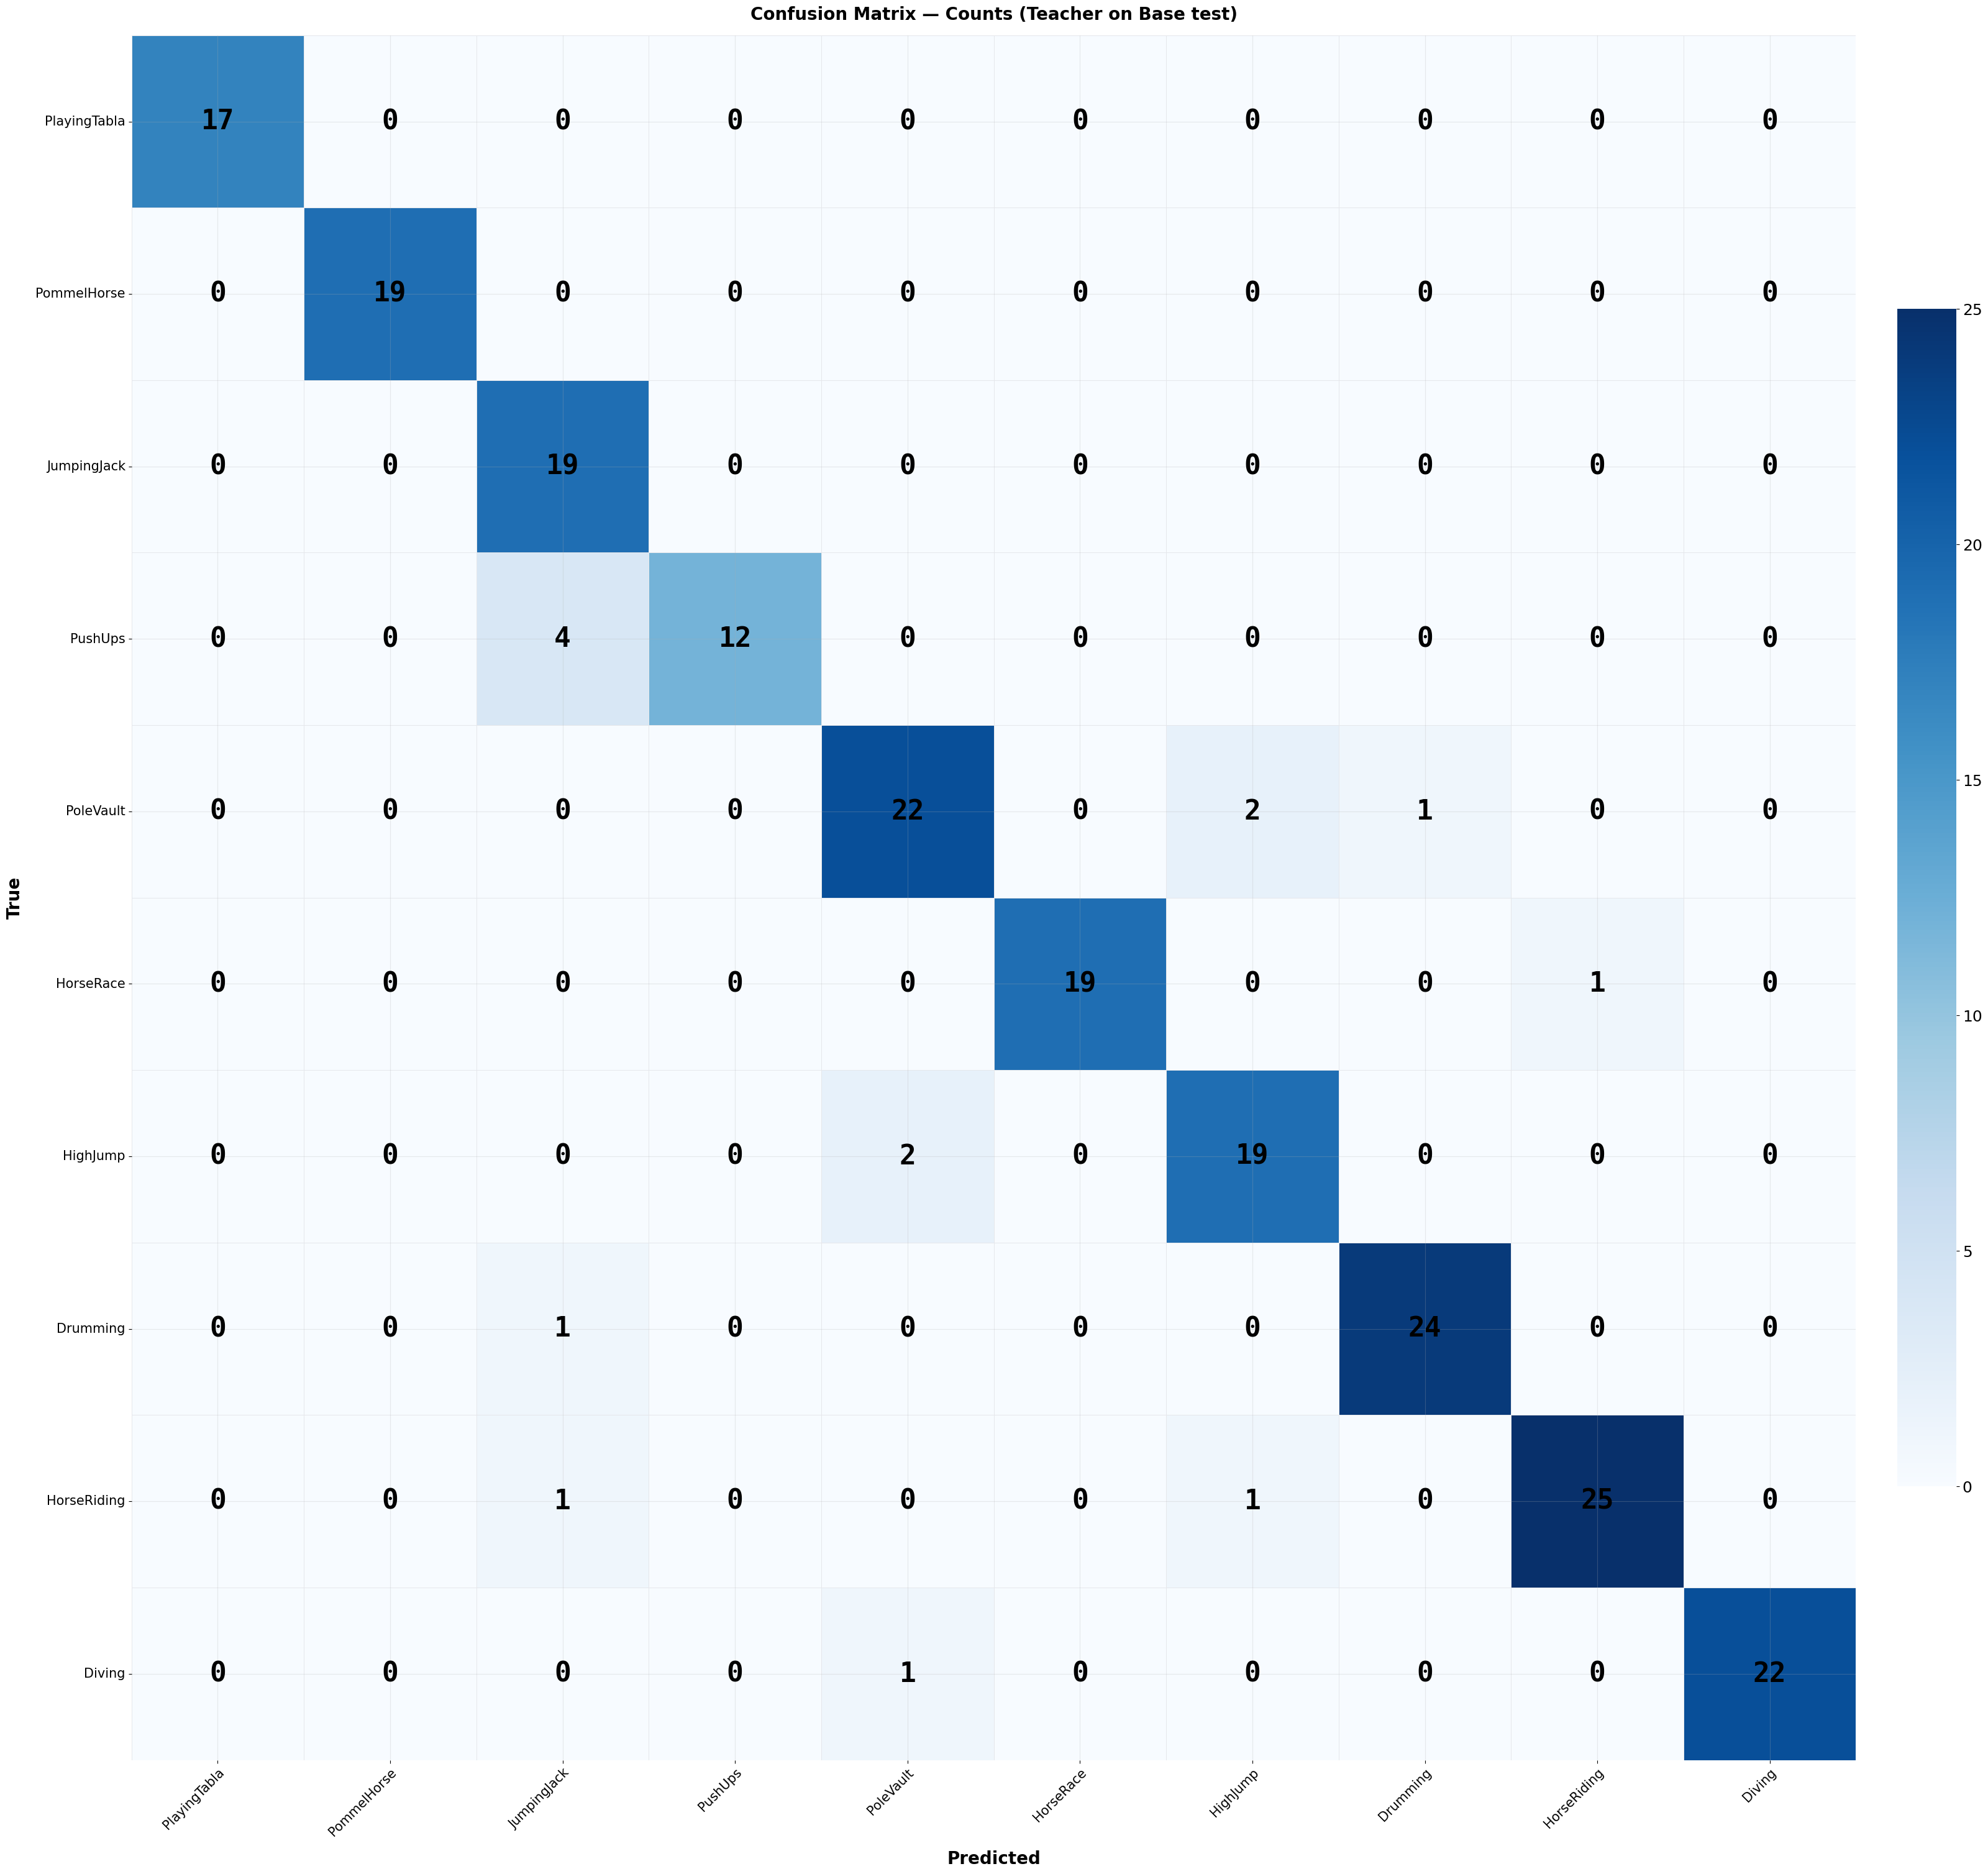

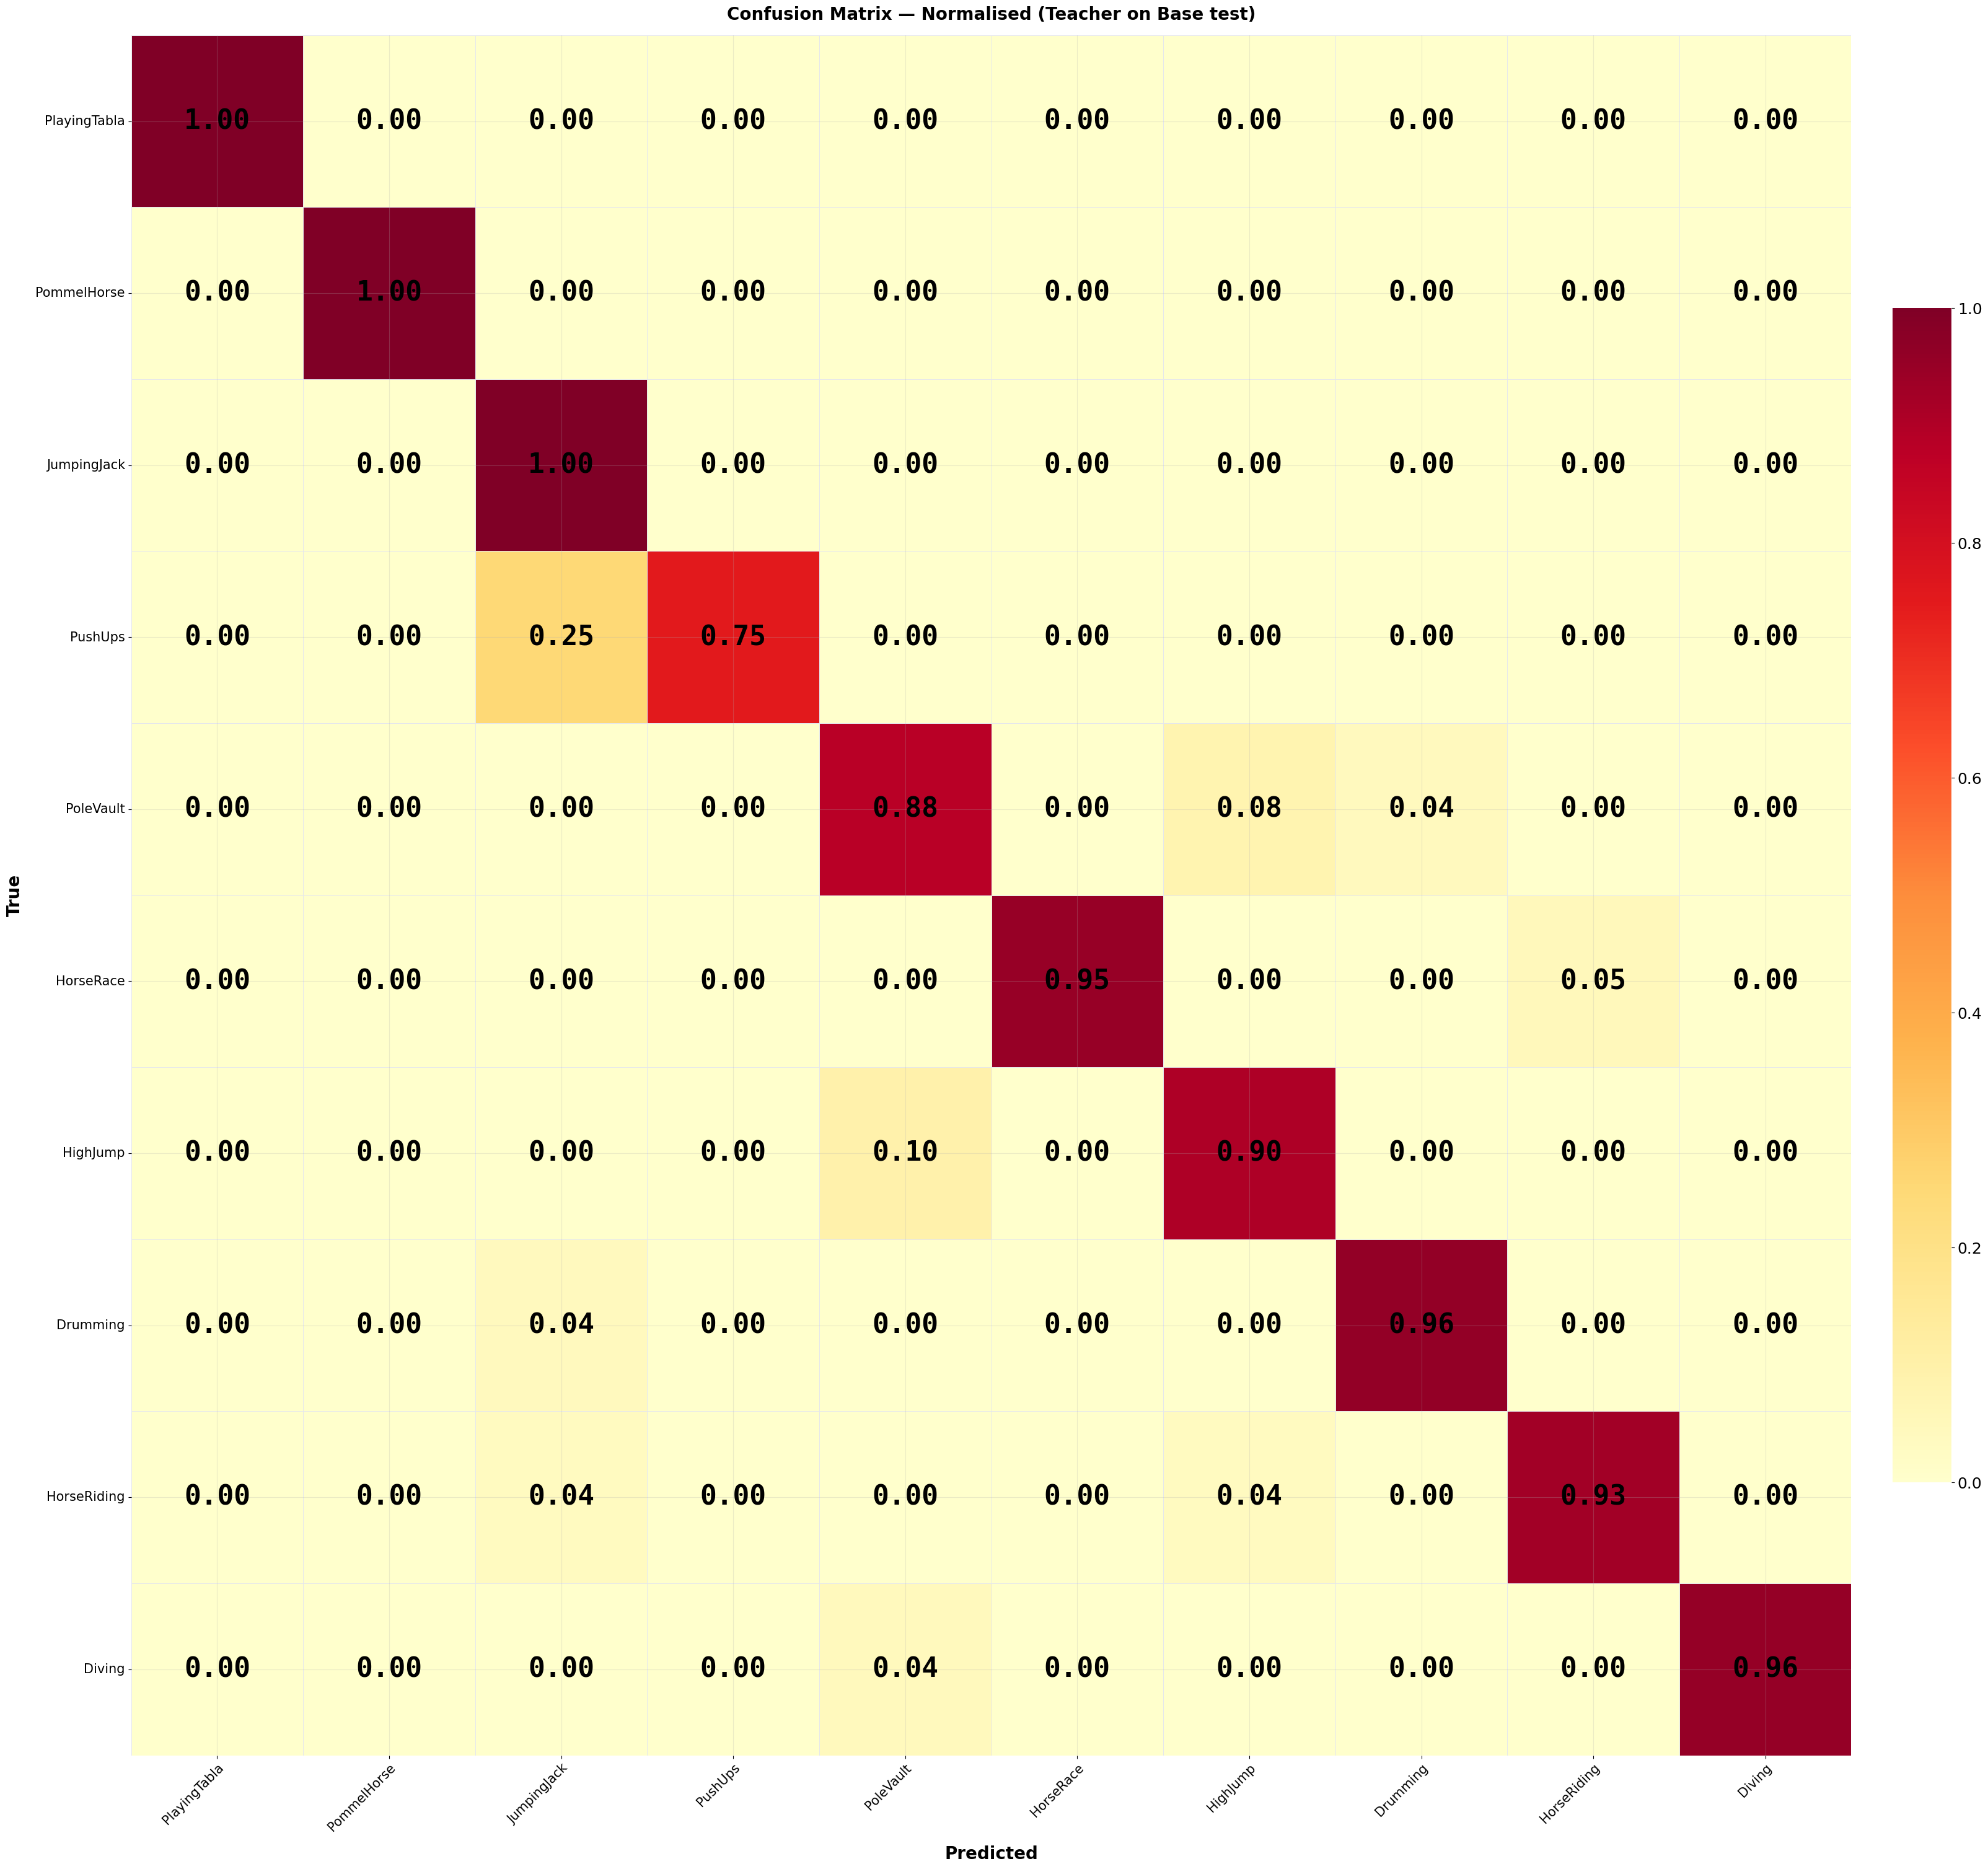

In [36]:
plot_confusion_matrix(
    base_labels, base_preds,
    num_classes  = len(cfg.SELECTED_CLASSES),
    classes_list = cfg.SELECTED_CLASSES,
    name         = "Teacher on Base test",
    save_path    = f"{cfg.RESULTS_DIR}/cm_teacher_base",
)

In [37]:
print_detailed_metrics(
    all_labels   = base_labels,
    all_preds    = base_preds,
    num_classes  = len(cfg.SELECTED_CLASSES),
    classes_list = cfg.SELECTED_CLASSES,
)


METRICS FOR 10 CLASSES
OVERALL (Weighted Average)
  Accuracy  : 0.9340
  Precision : 0.9412
  Recall    : 0.9340
  F1-Score  : 0.9346

PER-CLASS REPORT 
              precision    recall  f1-score   support

PlayingTabla       1.00      1.00      1.00        17
 PommelHorse       1.00      1.00      1.00        19
 JumpingJack       0.76      1.00      0.86        19
     PushUps       1.00      0.75      0.86        16
   PoleVault       0.88      0.88      0.88        25
   HorseRace       1.00      0.95      0.97        20
    HighJump       0.86      0.90      0.88        21
    Drumming       0.96      0.96      0.96        25
 HorseRiding       0.96      0.93      0.94        27
      Diving       1.00      0.96      0.98        23

    accuracy                           0.93       212
   macro avg       0.94      0.93      0.93       212
weighted avg       0.94      0.93      0.93       212

TOP 5 BEST CLASSES (F1)
  1. PlayingTabla             : 1.0000
  2. PommelHorse        

## **Extract Embeddings**

Run the frozen backbone over every clip and keep the per-frame `(16, 2048)` output.

Splits are cached separately and never mixed: train fits, val selects, test reports.
Stored as fp16 to halve the file, cast back to fp32 at load time because the LSTM
needs fp32.

In [38]:
STORE_DTYPE = getattr(torch, cfg.STORE_DTYPE)

FEATS = {}

In [39]:
# BASE
base_train_f, base_train_y = extract_frame_features(teacher.backbone, base_train_loader, device, cfg.BACKBONE_DIM, STORE_DTYPE)
base_val_f,   base_val_y   = extract_frame_features(teacher.backbone, base_val_loader,   device, cfg.BACKBONE_DIM, STORE_DTYPE)
base_test_f,  base_test_y  = extract_frame_features(teacher.backbone, base_test_loader,  device, cfg.BACKBONE_DIM, STORE_DTYPE)

FEATS["t0_train"] = (base_train_f, base_train_y)
FEATS["t0_val"]   = (base_val_f,   base_val_y)
FEATS["t0_test"]  = (base_test_f,  base_test_y)

print(f"t0_train {tuple(base_train_f.shape)}   t0_val {tuple(base_val_f.shape)}   t0_test {tuple(base_test_f.shape)}")

  Frame features: 100%|██████████| 27/27 [00:10<00:00,  2.49it/s]

t0_train (953, 16, 2048)   t0_val (165, 16, 2048)   t0_test (212, 16, 2048)


In [40]:
# TASK 1
task1_train_f, task1_train_y = extract_frame_features(teacher.backbone, task1_train_loader, device, cfg.BACKBONE_DIM, STORE_DTYPE)
task1_val_f,   task1_val_y   = extract_frame_features(teacher.backbone, task1_val_loader,   device, cfg.BACKBONE_DIM, STORE_DTYPE)
task1_test_f,  task1_test_y  = extract_frame_features(teacher.backbone, task1_test_loader,  device, cfg.BACKBONE_DIM, STORE_DTYPE)

FEATS["t1_train"] = (task1_train_f, task1_train_y)
FEATS["t1_val"]   = (task1_val_f,   task1_val_y)
FEATS["t1_test"]  = (task1_test_f,  task1_test_y)

print(f"t1_train {tuple(task1_train_f.shape)}   t1_val {tuple(task1_val_f.shape)}   t1_test {tuple(task1_test_f.shape)}")

  Frame features: 100%|██████████| 28/28 [00:11<00:00,  2.48it/s]

t1_train (936, 16, 2048)   t1_val (153, 16, 2048)   t1_test (217, 16, 2048)


In [41]:
# TASK 2
task2_train_f, task2_train_y = extract_frame_features(teacher.backbone, task2_train_loader, device, cfg.BACKBONE_DIM, STORE_DTYPE)
task2_val_f,   task2_val_y   = extract_frame_features(teacher.backbone, task2_val_loader,   device, cfg.BACKBONE_DIM, STORE_DTYPE)
task2_test_f,  task2_test_y  = extract_frame_features(teacher.backbone, task2_test_loader,  device, cfg.BACKBONE_DIM, STORE_DTYPE)

FEATS["t2_train"] = (task2_train_f, task2_train_y)
FEATS["t2_val"]   = (task2_val_f,   task2_val_y)
FEATS["t2_test"]  = (task2_test_f,  task2_test_y)

print(f"t2_train {tuple(task2_train_f.shape)}   t2_val {tuple(task2_val_f.shape)}   t2_test {tuple(task2_test_f.shape)}")

  Frame features: 100%|██████████| 29/29 [00:11<00:00,  2.44it/s]

t2_train (991, 16, 2048)   t2_val (158, 16, 2048)   t2_test (226, 16, 2048)


The Task-0 LSTM weights are saved next to the features, so every later notebook starts
its LSTM from the same place.

In [42]:
save_feature_cache(
    cfg.FEAT_CACHE, FEATS, teacher.lstm.state_dict(),
    cfg.BACKBONE_DIM, cfg.CLIP_LEN, ALL_CLASSES_LIST, TASK_NAMES,
)

Saved 263 MB -> /content/drive/MyDrive/apai/cache/ulal_frame_features.pt


In [43]:
del teacher
del model_teacher
if torch.cuda.is_available():
    torch.cuda.empty_cache()

print("Teacher released")

Teacher released


## **Verify Cache**

Load it back from Drive, exactly the way notebooks 4.1 to 4.6 will, and check the
shapes and that no task's labels leaked into another task's tensors.

In [44]:
CACHE, LSTM_STATE, META = load_feature_cache(cfg.FEAT_CACHE)

print(f"\ncached label space: {META['global_classes']}")
print(f"task names        : {META['task_names']}")

Loaded 9 tensors, 526 MB in RAM
  per clip: (16, 2048)

cached label space: ['PlayingTabla', 'PommelHorse', 'JumpingJack', 'PushUps', 'PoleVault', 'HorseRace', 'HighJump', 'Drumming', 'HorseRiding', 'Diving', 'ApplyEyeMakeup', 'ApplyLipstick', 'Archery', 'BabyCrawling', 'BalanceBeam', 'BandMarching', 'BlowDryHair', 'BlowingCandles', 'BodyWeightSquats', 'Bowling', 'BoxingPunchingBag', 'BoxingSpeedBag', 'BrushingTeeth', 'CliffDiving', 'CricketBowling', 'CricketShot', 'CuttingInKitchen', 'FieldHockeyPenalty', 'Haircut', 'SoccerPenalty']
task names        : ['Base', 'Task1', 'Task2']


In [45]:
print_cache_summary(CACHE, TASK_NAMES)

key           clips           shape  classes      MB
----------------------------------------------------
t0_test         212      (16, 2048)       10    27.8
t0_train        953      (16, 2048)       10   124.9
t0_val          165      (16, 2048)       10    21.6
t1_test         217      (16, 2048)       10    28.4
t1_train        936      (16, 2048)       10   122.7
t1_val          153      (16, 2048)       10    20.1
t2_test         226      (16, 2048)       10    29.6
t2_train        991      (16, 2048)       10   129.9
t2_val          158      (16, 2048)       10    20.7
----------------------------------------------------
TOTAL          4011                            525.7


In [46]:
verify_cache(CACHE, TASK_CLASSES, class_to_idx, cfg.BACKBONE_DIM, cfg.CLIP_LEN)

OK — 4011 clips, tasks disjoint, train/val/test separate.
raw video would be 38,641 MB   cache is 526 MB (74x smaller)


4011

## **Embedding Quality**

The ResNet was fine-tuned on 10 sports classes and then frozen. Do its features still
carry the new classes, makeup and boxing, or did the fine-tuning throw that away?

Each clip is mean-pooled from `(16, 2048)` to `(2048,)` and a simple classifier is
asked to separate the classes. 1-NN is pure geometry with nothing learned; the linear
probe measures how much linearly separable information is there.

The **joint linear probe is the ceiling**. If it reads 90%, then no continual-learning
method in notebook 4 can beat 90%, and every result there is read against this number.

In [47]:
report = probe_report(CACHE, TASK_NAMES, k=1)

Group      classes   chance     1-NN   linear  vs chance
--------------------------------------------------------
Base            10    10.0%    89.6%    94.8%    +84.8%
Task1           10    10.0%    85.3%    88.9%    +78.9%
Task2           10    10.0%    76.1%    86.7%    +76.7%
JOINT           30     3.3%    71.5%    82.4%    +79.1% <-- all tasks together
--------------------------------------------------------
VERDICT: frozen features separate the classes well.
         Representation is NOT the bottleneck — later drops are forgetting.


Silhouette score, in [-1, 1], says how tight and well separated the class clusters are.
Near 0 means clusters overlap heavily.

In [48]:
task_ids = [0, 1, 2]

sil_base  = separability(CACHE, [0])
sil_task1 = separability(CACHE, [1])
sil_task2 = separability(CACHE, [2])
sil_joint = separability(CACHE, task_ids)

print(f"{'Group':<10}{'silhouette':>12}")
print("-" * 22)
print(f"{'Base':<10}{sil_base:>12.3f}")
print(f"{'Task1':<10}{sil_task1:>12.3f}")
print(f"{'Task2':<10}{sil_task2:>12.3f}")
print(f"{'JOINT':<10}{sil_joint:>12.3f}")

Group       silhouette
----------------------
Base             0.377
Task1            0.085
Task2            0.061
JOINT            0.100


Classes whose centroids sit close together are the ones that will compete during
continual learning. A close pair that crosses tasks predicts exactly where the
confusion matrices in notebook 4 will go wrong, before any training happens.

In [49]:
cents        = class_centroids(CACHE, task_ids, "train")
labels, dist = centroid_distances(cents)

print_closest_pairs(cents, ALL_CLASSES_LIST, TASK_CLASSES, TASK_NAMES, top=10)

    dist  class A                class B                tasks
--------------------------------------------------------------------
    3.51  BlowDryHair            Haircut                [Task1/Task2]  <- different tasks
    3.67  CricketBowling         CricketShot            [Task2/Task2]
    4.67  ApplyEyeMakeup         ApplyLipstick          [Task1/Task1]
    4.73  ApplyLipstick          BrushingTeeth          [Task1/Task2]  <- different tasks
    4.90  BoxingPunchingBag      BoxingSpeedBag         [Task2/Task2]
    4.92  BrushingTeeth          Haircut                [Task2/Task2]
    4.98  BlowDryHair            BrushingTeeth          [Task1/Task2]  <- different tasks
    5.44  BlowDryHair            BoxingSpeedBag         [Task1/Task2]  <- different tasks
    5.66  ApplyEyeMakeup         BrushingTeeth          [Task1/Task2]  <- different tasks
    5.79  ApplyEyeMakeup         Haircut                [Task1/Task2]  <- different tasks


## **Latent Space**

Four views of the same cache: the probe scores, the features coloured by task, the same
features coloured by class, and the centroid distance heatmap.

In [50]:
task_of = {}
for t, group in enumerate(TASK_CLASSES):
    for c in group:
        task_of[class_to_idx[c]] = t

xy, lab = project_2d(CACHE, task_ids, split="train", method="tsne", seed=cfg.SEED)

print(f"projected {len(xy)} clips")

projected 2000 clips


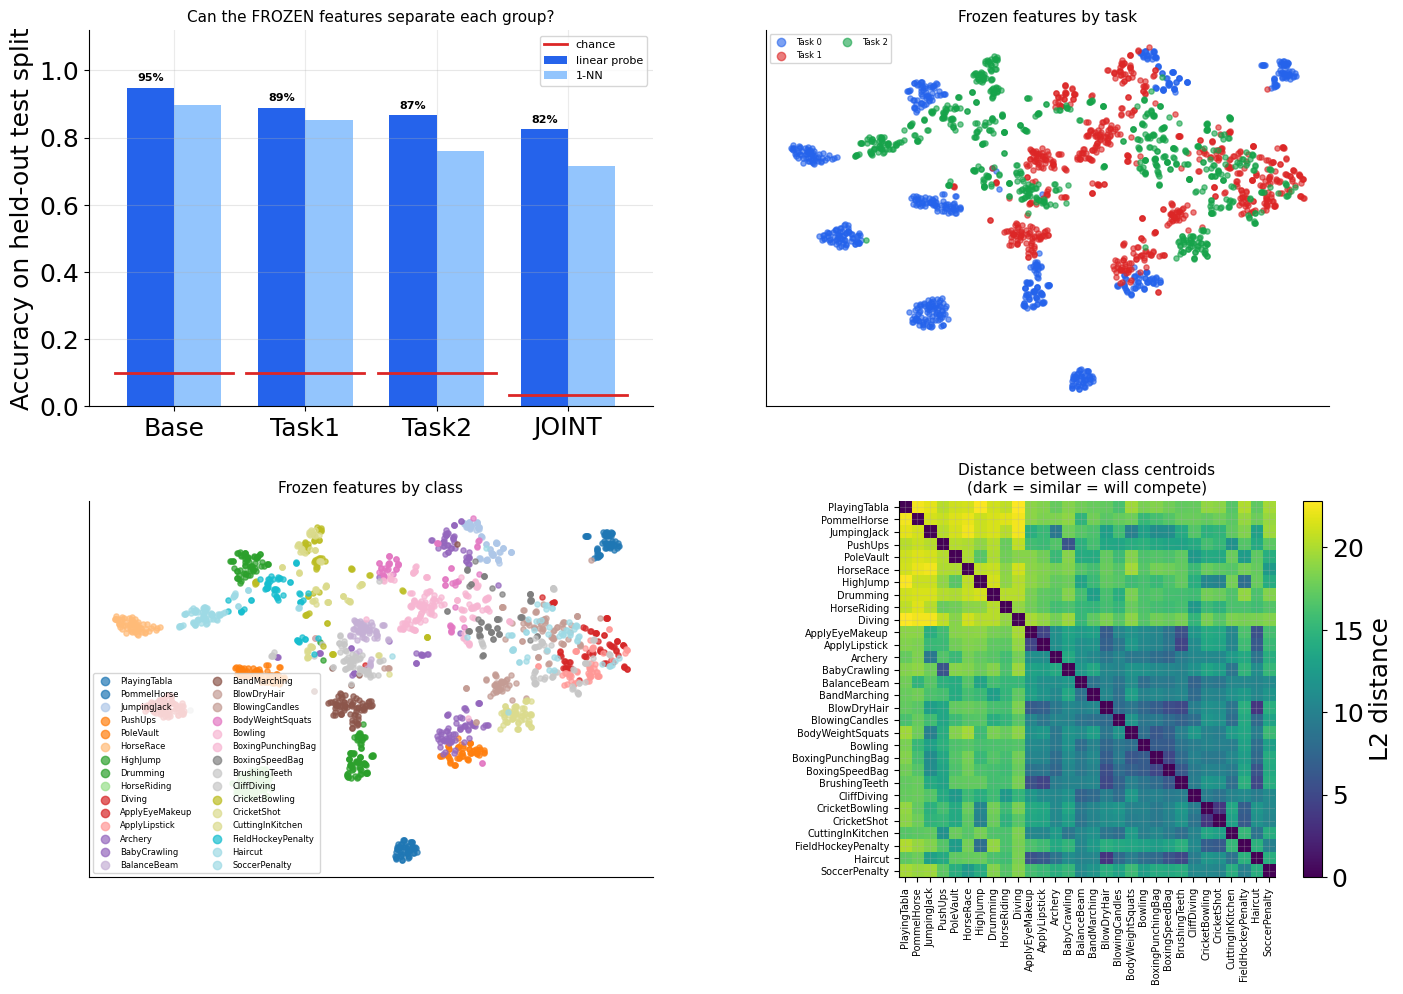

In [51]:
fig = plt.figure(figsize=(16, 11))
gs  = fig.add_gridspec(2, 2, hspace=0.25, wspace=0.2)

plot_probe_bars(report, ax=fig.add_subplot(gs[0, 0]))
plot_latent_space(xy, lab, ALL_CLASSES_LIST, task_of=task_of,
                  title="Frozen features by task", ax=fig.add_subplot(gs[0, 1]))
plot_latent_space(xy, lab, ALL_CLASSES_LIST,
                  title="Frozen features by class", ax=fig.add_subplot(gs[1, 0]))
plot_centroid_heatmap(labels, dist, ALL_CLASSES_LIST, ax=fig.add_subplot(gs[1, 1]))

plt.savefig(f"{cfg.RESULTS_DIR}/stage2_embedding_diagnostics.png", dpi=150, bbox_inches="tight")
plt.show()

## **Save**

The cache itself is already on Drive. This saves the diagnostics next to it so notebook
4 can quote the ceiling without recomputing it.

In [52]:
diag = {
    "stage":            "2_embedding_quality",
    "classes":          ALL_CLASSES_LIST,
    "task_names":       TASK_NAMES,
    "teacher_base_acc": float(base_acc),
    "probe":            report,
    "silhouette":       {"Base": sil_base, "Task1": sil_task1, "Task2": sil_task2},
    "silhouette_joint": sil_joint,
    "ceiling":          report["JOINT"]["linear"],
    "n_clips":          int(sum(f.shape[0] for f, _ in CACHE.values())),
}

os.makedirs(cfg.RESULTS_DIR, exist_ok=True)
with open(f"{cfg.RESULTS_DIR}/stage2_embedding_diagnostics.json", "w") as f:
    json.dump(diag, f, indent=2, default=float)

print(f"Saved -> {cfg.RESULTS_DIR}/stage2_embedding_diagnostics.json")

Saved -> /content/drive/MyDrive/apai/results/stage2_embedding_diagnostics.json


In [53]:
print(f"cache            : {cfg.FEAT_CACHE}")
print(f"teacher base acc : {base_acc:.2%}")
print(f"JOINT 1-NN       : {report['JOINT']['knn']:.2%}")
print(f"JOINT linear     : {report['JOINT']['linear']:.2%}   <- ceiling for notebook 4")
print(f"chance           : {report['JOINT']['chance']:.2%}")

cache            : /content/drive/MyDrive/apai/cache/ulal_frame_features.pt
teacher base acc : 93.40%
JOINT 1-NN       : 71.45%
JOINT linear     : 82.44%   <- ceiling for notebook 4
chance           : 3.33%
